In [22]:
import os

base_path = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
categories = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

for category in categories:
    image_files = set(os.listdir(os.path.join(base_path, category, "images")))
    mask_files = set(os.listdir(os.path.join(base_path, category, "masks")))

    print(f"{category}:")
    print(f"  Képek száma: {len(image_files)}")
    print(f"  Maszkok száma: {len(mask_files)}")
    print(f"  Hiányzó maszkok száma: {len(image_files - mask_files)}\n")


COVID:
  Képek száma: 3616
  Maszkok száma: 3616
  Hiányzó maszkok száma: 0

Lung_Opacity:
  Képek száma: 6012
  Maszkok száma: 6012
  Hiányzó maszkok száma: 0

Normal:
  Képek száma: 10192
  Maszkok száma: 10192
  Hiányzó maszkok száma: 0

Viral Pneumonia:
  Képek száma: 1345
  Maszkok száma: 1345
  Hiányzó maszkok száma: 0



In [23]:
import pandas as pd

meta_path = os.path.join(base_path, "COVID.metadata.xlsx")
df = pd.read_excel(meta_path)

df.head()  # Első 5 sor megtekintése


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


In [24]:
import os
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset

In [25]:
# CUDA beállítása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adatmappa és osztályok
data_dir = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
categories = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
image_size = 224  # ResNet bemenet mérete
batch_size = 32   # GPU-ra egyszerre küldött képek száma

# Képtranszformációk
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Using device: cuda


In [26]:
# Saját dataset osztály
class ChestXRayDataset(Dataset):
    def __init__(self, data_dir, categories, transform, sample_size=500):
        self.images = []
        self.labels = []
        self.class_names = []
        self.transform = transform
        self.label_map = {cat: i for i, cat in enumerate(categories)}
        self.inv_label_map = {i: cat for cat, i in self.label_map.items()}  # Szám → név átalakítás

        for category in categories:
            path = os.path.join(data_dir, category, "images")
            files = os.listdir(path)[:sample_size]  # Max sample_size képet töltünk
            for file in tqdm(files, desc=f"Loading {category} images"):
                img_path = os.path.join(path, file)
                img = Image.open(img_path).convert("RGB")
                self.images.append(img)
                self.labels.append(self.label_map[category])
                self.class_names.append(category)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.transform(self.images[idx])  # Transformálás
        label = self.labels[idx]
        return img, label
    

In [27]:
# Adatbetöltő létrehozása
dataset = ChestXRayDataset(data_dir, categories, transform, sample_size=500)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ResNet50 feature extractor beállítása
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)

# Feature-ek kinyerése batchenként
features = []
labels = []

with torch.no_grad():
    for images, batch_labels in tqdm(dataloader, desc="Extracting features"):
        images = images.to(device)  # GPU-ra küldés
        batch_features = feature_extractor(images).squeeze()  # (N, 2048, 1, 1) → (N, 2048)
        features.append(batch_features.cpu().numpy())  # CPU-ra visszavitel
        labels.extend(batch_labels.numpy())  # NumPy listába

# NumPy tömbbé alakítás
features = np.vstack(features)  # (összes_kép, 2048)
labels = np.array(labels)

Loading Viral Pneumonia images: 100%|██████████| 500/500 [00:01<00:00, 282.98it/s]
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.

Extracting features: 100%|██████████| 63/63 [00:06<00:00,  9.65it/s]


In [28]:
# Osztálynevek visszaállítása a számok helyett
label_names = np.array([dataset.inv_label_map[label] for label in labels])

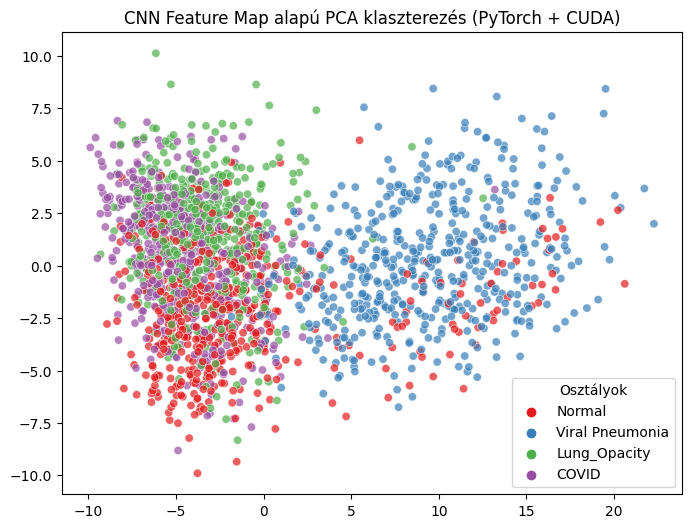

In [29]:
# PCA dimenziócsökkentés
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=label_names, alpha=0.7, palette="Set1")
plt.title("CNN Feature Map alapú PCA klaszterezés (PyTorch + CUDA)")
plt.legend(title="Osztályok")
plt.show()

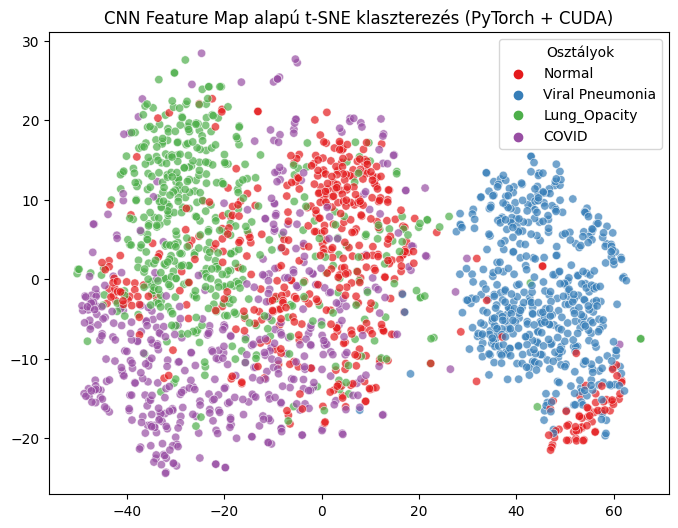

In [30]:
# t-SNE dimenziócsökkentés
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=label_names, alpha=0.7, palette="Set1")
plt.title("CNN Feature Map alapú t-SNE klaszterezés (PyTorch + CUDA)")
plt.legend(title="Osztályok")
plt.show()

In [31]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA dimenziócsökkentés 3 komponensre
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(features)

# t-SNE dimenziócsökkentés 3 komponensre
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_3d_result = tsne_3d.fit_transform(features)

# Osztályok nevének hozzárendelése
label_names = np.array(label_names)

In [32]:
#  Interaktív PCA 3D scatter plot
fig_pca = px.scatter_3d(
    x=pca_3d_result[:, 0], 
    y=pca_3d_result[:, 1], 
    z=pca_3d_result[:, 2], 
    color=label_names,
    title="CNN Feature Map alapú PCA klaszterezés (3D, interaktív)",
    labels={"x": "PC1", "y": "PC2", "z": "PC3"}
)

#  Interaktív t-SNE 3D scatter plot
fig_tsne = px.scatter_3d(
    x=tsne_3d_result[:, 0], 
    y=tsne_3d_result[:, 1], 
    z=tsne_3d_result[:, 2], 
    color=label_names,
    title="CNN Feature Map alapú t-SNE klaszterezés (3D, interaktív)",
    labels={"x": "t-SNE1", "y": "t-SNE2", "z": "t-SNE3"}
)

In [33]:
# Megjelenítés
fig_pca.show()

In [34]:
fig_tsne.show()

In [35]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
from tqdm import tqdm

In [36]:
# Adatmappa
data_dir = "/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset"
categories = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# Képtranszformációk
transform_CNN = transforms.Compose([
    transforms.Resize((256, 256)),  # ResNet bemeneti mérete
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Módosított ChestXRayDataset osztály
class ChestXRayDatasetCNN(Dataset):
    def __init__(self, data_dir, categories, transform_CNN):
        self.image_paths = []
        self.labels = []
        self.transform = transform_CNN
        self.label_map = {cat: i for i, cat in enumerate(categories)}

        for category in categories:
            path = os.path.join(data_dir, category, "images")
            files = os.listdir(path)  # Összes fájl beolvasása
            for file in files:
                self.image_paths.append(os.path.join(path, file))
                self.labels.append(self.label_map[category])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

# Adathalmaz betöltése
dataset_CNN = ChestXRayDatasetCNN(data_dir, categories, transform_CNN)

# Train / Validáció / Teszt felosztás (80% / 10% / 10%)
train_size = int(0.8 * len(dataset_CNN))
val_size = int(0.1 * len(dataset_CNN))
test_size = len(dataset_CNN) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset_CNN, [train_size, val_size, test_size])

num_workers = os.cpu_count()

# Dataloader-ek létrehozása
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,num_workers=num_workers)

print(f"Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 16932, Validation: 2116, Test: 2117


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = F.softmax(preds, dim=1)  # Aktivációs függvény
        
        # Debugging print
        print("Targets shape before processing:", targets.shape)

        # Ha a `targets` (N, 1, H, W) alakú, alakítsuk (N, H, W)-re
        if targets.dim() == 4 and targets.shape[1] == 1:
            targets = targets.squeeze(1)
        
        # Ha a `targets` (N,) alakú, az azt jelenti, hogy nincs térbeli dimenzió -> hibás
        if targets.dim() == 1:
            raise ValueError(f"Invalid shape for targets: {targets.shape}. Expected (N, H, W) or (N, 1, H, W)")

        # One-hot encoding és átalakítás NCHW formátumra
        targets_one_hot = F.one_hot(targets.long(), num_classes=preds.shape[1])  # (N, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (N, C, H, W)

        intersection = torch.sum(preds * targets_one_hot, dim=(2, 3))
        union = torch.sum(preds, dim=(2, 3)) + torch.sum(targets_one_hot, dim=(2, 3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CombinedLoss(torch.nn.Module):
    def __init__(self, alpha=0.5):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.ce_loss = torch.nn.CrossEntropyLoss()
        self.dice_loss = DiceLoss()

    def forward(self, preds, targets):
        return self.alpha * self.ce_loss(preds, targets) + (1 - self.alpha) * self.dice_loss(preds, targets)

<ipython-input-38-06706c14163c>:14: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

Epoch 1/10 - Training:   0%|          | 0/133 [00:00<?, ?it/s]<ipython-input-38-06706c14163c>:50: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

Epoch 1/10 - Training: 100%|██████████| 133/133 [00:47<00:00,  2.79it/s]



Epoch 1/10: Train Loss: 0.3884, Train Acc: 0.8672, Val Loss: 0.2011, Val Acc: 0.9301


Epoch 2/10 - Training: 100%|██████████| 133/133 [00:42<00:00,  3.16it/s]



Epoch 2/10: Train Loss: 0.1315, Train Acc: 0.9551, Val Loss: 0.1790, Val Acc: 0.9376


Epoch 3/10 - Training: 100%|██████████| 133/133 [00:42<00:00,  3.16it/s]


...


Epoch 9/10: Train Loss: 0.0015, Train Acc: 1.0000, Val Loss: 0.1923, Val Acc: 0.9537


Epoch 10/10 - Training: 100%|██████████| 133/133 [00:42<00:00,  3.16it/s]



Epoch 10/10: Train Loss: 0.0012, Train Acc: 1.0000, Val Loss: 0.2055, Val Acc: 0.9513


Testing: 100%|██████████| 67/67 [00:05<00:00, 12.69it/s]



Teszt Loss: 0.2987, Teszt Pontosság: 0.9400


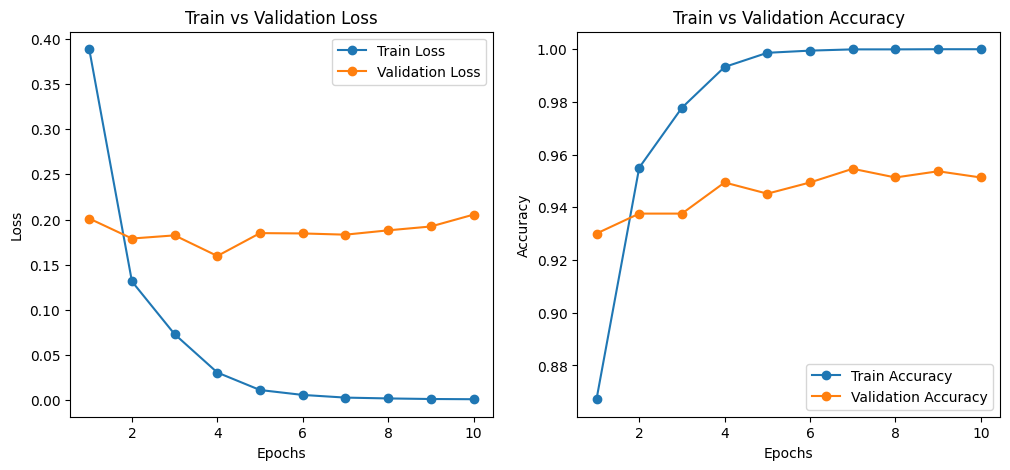

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm import tqdm

# CUDA optimalizációk
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True

# GPU beállítás
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = torch.cuda.amp.GradScaler()  # Automatikus Mixed Precision (AMP)

# Modell betöltése (ResNet18 finomhangolás)
class COVIDClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(COVIDClassifier, self).__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Modell inicializálása
num_classes = len(categories)
model = COVIDClassifier(num_classes).to(device)

# # Loss függvény és optimalizáló
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()  # Dice loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


# Tanítási függvény + teszt kiértékelés
def train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=10, accumulation_steps=2):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        optimizer.zero_grad()

        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training")):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():  # Mixed Precision
                outputs = model(images)
                loss = criterion(outputs, labels) / accumulation_steps

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or i == len(train_loader) - 1:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * accumulation_steps * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # Validáció
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # Eredmények mentése
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Tesztelés
    model.eval()
    test_loss, test_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            test_correct += (outputs.argmax(1) == labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = test_correct / len(test_loader.dataset)

    print(f"\nTeszt Loss: {test_loss:.4f}, Teszt Pontosság: {test_acc:.4f}")

    plot_training_history(history)

# Grafikon rajzolás
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    plt.plot(epochs, history["val_loss"], label="Validation Loss", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Train vs Validation Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy", marker="o")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Train vs Validation Accuracy")

    plt.show()

# Tanítás és tesztelés
train_and_evaluate(model, train_loader, val_loader, test_loader, epochs=10, accumulation_steps=4)

# Modell mentése
torch.save(model.state_dict(), "covid_classifier.pth")


<ipython-input-39-b105e43d3ee1>:12: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



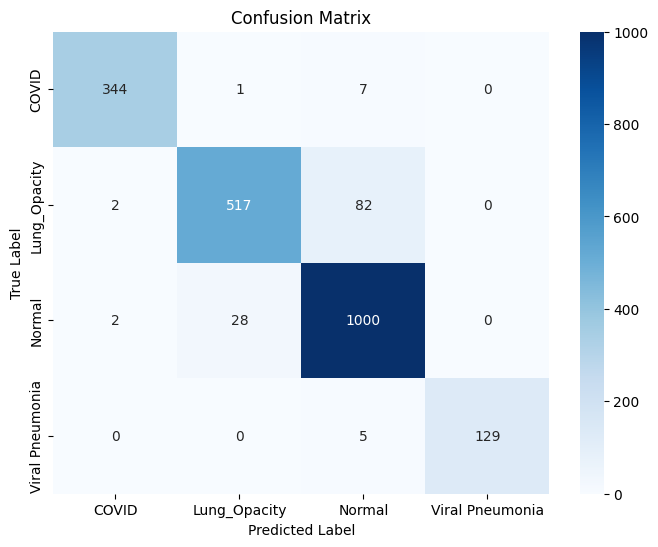


Classification Report:
                 precision    recall  f1-score   support

          COVID     0.9885    0.9773    0.9829       352
   Lung_Opacity     0.9469    0.8602    0.9015       601
         Normal     0.9141    0.9709    0.9416      1030
Viral Pneumonia     1.0000    0.9627    0.9810       134

       accuracy                         0.9400      2117
      macro avg     0.9624    0.9428    0.9517      2117
   weighted avg     0.9412    0.9400    0.9396      2117

Weighted F1-score: 0.9396
Weighted Precision: 0.9412
Weighted Recall: 0.9400
Dice Score for COVID: 0.9829
Dice Score for Lung_Opacity: 0.9015
Dice Score for Normal: 0.9416
Dice Score for Viral Pneumonia: 0.9810

Average Dice Score: 0.9517


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# GPU beállítás
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell betöltése és kiértékelés előkészítése
model = COVIDClassifier(num_classes=len(categories)).to(device)
model.load_state_dict(torch.load("covid_classifier.pth"))
model.eval()

# Metrikák számítása
def evaluate_model(model, test_loader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Konfúziós mátrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    # Osztályozási riport (Precision, Recall, F1-score)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=categories, digits=4))

    # F1, Precision, Recall metrikák külön
    f1 = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")

    print(f"Weighted F1-score: {f1:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")

    # Dice Score kiszámítása minden osztályra
    dice_scores = []
    for class_idx in range(len(categories)):
        true_class = (np.array(y_true) == class_idx).astype(int)
        pred_class = (np.array(y_pred) == class_idx).astype(int)

        intersection = np.sum(true_class * pred_class)
        dice = (2.0 * intersection) / (np.sum(true_class) + np.sum(pred_class) + 1e-6)
        dice_scores.append(dice)

    # Dice Score kiírása
    for i, category in enumerate(categories):
        print(f"Dice Score for {category}: {dice_scores[i]:.4f}")

    # Átlagos Dice Score
    avg_dice = np.mean(dice_scores)
    print(f"\nAverage Dice Score: {avg_dice:.4f}")

# Kiértékelés futtatása
evaluate_model(model, test_loader)


In [40]:
torch.save(model,"full_model.pth")